# Project 7: Marketing Campaign Performance Analysis for an E-Commerce Company

## 1. Project Overview

This project analyses customer behaviour and marketing campaign performance for an e-commerce business.

The objective is to identify which customer segments generate the most revenue, evaluate the effectiveness of historical marketing campaigns, and determine whether recent campaigns are successfully targeting high-value customers.

SQL is used to query and aggregate the data, while Python is used for visualisation and business insight generation.

## Dataset

The dataset contains **2,240 customer records** and includes demographic information, household characteristics, product spending, and responses to historical marketing campaigns.

Key variables used in this analysis include:

- Education level
- Marital status
- Number of children in the household
- Customer tenure
- Spending across multiple product categories
- Historical campaign responses
- Response to the latest marketing campaign

## Data Cleaning and Feature Engineering

The dataset required light cleaning before analysis:
- Loaded using tab separation due to file formatting
- Removed constant columns (`Z_CostContact`, `Z_Revenue`)
- Converted `Dt_Customer` to datetime format
- Created a `Total_Spend` variable by summing product spend columns
- Created `Customer_Tenure_Days` to measure customer longevity

### Load packages and data set

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    r"C:\Users\Lenovo\Data_Analysis_Business\Project7_marketing_analytics\marketing_campaign.csv",
    sep="\t"
)

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


### Inspect the data

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [3]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


### Clean the data

Convert date column

In [4]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y")

check missing values

In [5]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

drop the constant columns

In [6]:
df = df.drop(["Z_CostContact", "Z_Revenue"], axis=1)

## SQL Analysis

SQL queries are used to aggregate customer data and identify patterns in spending behaviour, marketing campaign performance, and customer segmentation.

The following queries examine:

- Average spend by education level
- Customer spending by relationship status
- Historical marketing campaign success rates
- Campaign response rates by customer value segment
- Spending behaviour by household type

### Create a total spend variable that combines all categories of expenditure

In [7]:
df["Total_Spend"] = (
    df["MntWines"]
    + df["MntFruits"]
    + df["MntMeatProducts"]
    + df["MntFishProducts"]
    + df["MntSweetProducts"]
    + df["MntGoldProds"]
)

In [8]:
df[["ID","Total_Spend"]].head()

,ID,Total_Spend
0,5524,1617
1,2174,27
2,4141,776
3,6182,53
4,5324,422


In [9]:
df["Total_Spend"].describe()

count    2240.000000
mean      605.798214
std       602.249288
min         5.000000
25%        68.750000
50%       396.000000
75%      1045.500000
max      2525.000000
Name: Total_Spend, dtype: float64

Create SQL database "marketing_analysis.db" from the Jupyter notebook

In [10]:
import sqlite3

conn = sqlite3.connect("marketing_analysis.db")

df.to_sql("customers", conn, if_exists="replace", index=False)

2240

I've created a table in SQL called "customers"

Test if it's worked

In [11]:
query = """
SELECT *
FROM customers
LIMIT 5
"""

pd.read_sql(query, conn)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Total_Spend
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04 00:00:00,58,635,...,4,7,0,0,0,0,0,0,1,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08 00:00:00,38,11,...,2,5,0,0,0,0,0,0,0,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21 00:00:00,26,426,...,10,4,0,0,0,0,0,0,0,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10 00:00:00,26,11,...,4,6,0,0,0,0,0,0,0,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19 00:00:00,94,173,...,6,5,0,0,0,0,0,0,0,422


## First SQL query - which education group spends the most money

In [12]:
query = """
SELECT
    Education,
    COUNT(*) AS num_customers,
    ROUND(AVG(Total_Spend), 2) AS avg_spend,
    ROUND(SUM(Total_Spend), 2) AS total_revenue
FROM customers
GROUP BY Education
ORDER BY avg_spend DESC
"""

education_spend = pd.read_sql(query, conn)

education_spend

,Education,num_customers,avg_spend,total_revenue
0,PhD,486,672.41,326791.0
1,Graduation,1127,619.90,698626.0
2,Master,370,611.78,226359.0
3,2n Cycle,203,496.53,100795.0
4,Basic,54,81.80,4417.0


### Visualise the SQL table in Python

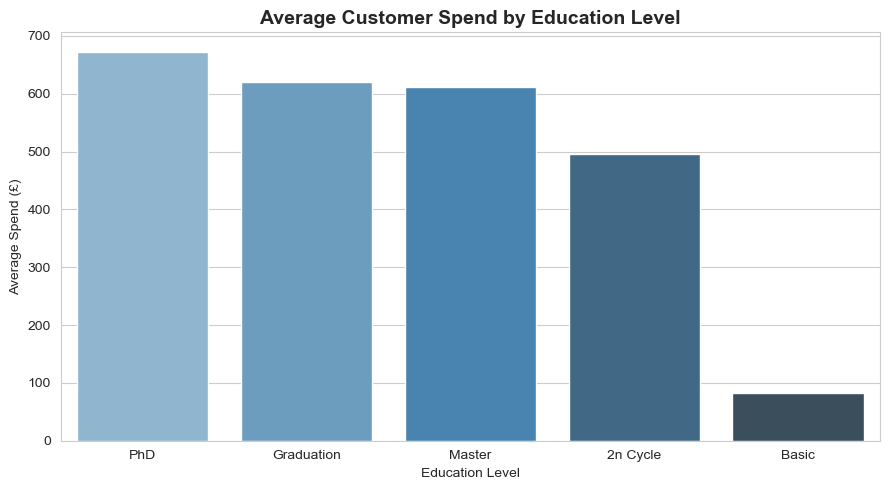

In [13]:
sns.set_style("whitegrid")

plt.figure(figsize=(9,5))

sns.barplot(
    data=education_spend,
    x="Education",
    y="avg_spend",
    hue="Education",
    palette="Blues_d",
    legend=False
)

plt.title("Average Customer Spend by Education Level", fontsize=14, weight="bold")
plt.xlabel("Education Level")
plt.ylabel("Average Spend (£)")

plt.tight_layout()
plt.savefig("education_level_spend.png", dpi=300, bbox_inches="tight")
plt.show()

## SQL Query 2 - How does spending differ by marital status?

In [14]:
query = """
SELECT
    Marital_Status,
    COUNT(*) AS num_customers,
    ROUND(AVG(Total_Spend),2) AS avg_spend,
    ROUND(SUM(Total_Spend),2) AS total_revenue
FROM customers
GROUP BY Marital_Status
ORDER BY avg_spend DESC
"""

marital_spend = pd.read_sql(query, conn)

marital_spend

,Marital_Status,num_customers,avg_spend,total_revenue
0,Absurd,2,1192.50,2385.0
1,Widow,77,738.82,56889.0
2,Divorced,232,610.63,141666.0
3,Together,580,608.39,352865.0
4,Single,480,606.48,291112.0
5,Married,864,590.80,510453.0
6,YOLO,2,424.00,848.0
7,Alone,3,256.67,770.0


### Tidy up data set to merge 3 categories with low numbers

In [15]:
query = """
SELECT
    CASE
        WHEN Marital_Status IN ('Married','Together') THEN 'Couple'
        ELSE 'Single'
    END AS relationship_status,

    COUNT(*) AS num_customers,
    ROUND(AVG(Total_Spend),2) AS avg_spend,
    ROUND(SUM(Total_Spend),2) AS total_revenue

FROM customers

GROUP BY relationship_status
ORDER BY avg_spend DESC
"""

relationship_spend = pd.read_sql(query, conn)

relationship_spend

,relationship_status,num_customers,avg_spend,total_revenue
0,Single,796,620.19,493670.0
1,Couple,1444,597.87,863318.0


## SQL Query 3 - Campaign success

In [16]:
query = """
SELECT
    ROUND(AVG(AcceptedCmp1)*100,2) AS campaign1_success_rate,
    ROUND(AVG(AcceptedCmp2)*100,2) AS campaign2_success_rate,
    ROUND(AVG(AcceptedCmp3)*100,2) AS campaign3_success_rate,
    ROUND(AVG(AcceptedCmp4)*100,2) AS campaign4_success_rate,
    ROUND(AVG(AcceptedCmp5)*100,2) AS campaign5_success_rate,
    ROUND(AVG(Response)*100,2) AS latest_campaign_success_rate
FROM customers
"""

campaign_performance = pd.read_sql(query, conn)

campaign_performance

,campaign1_success_rate,campaign2_success_rate,campaign3_success_rate,campaign4_success_rate,campaign5_success_rate,latest_campaign_success_rate
0,6.43,1.34,7.28,7.46,7.28,14.91


### Visualise campaign performance in Python

In [17]:
campaign_performance_t = campaign_performance.T
campaign_performance_t.columns = ["Success Rate (%)"]

campaign_performance_t.index = [
    "Campaign 1",
    "Campaign 2",
    "Campaign 3",
    "Campaign 4",
    "Campaign 5",
    "Latest Campaign"
]

### Campaign success rates

The following chart compares response rates across five historical marketing campaigns and the most recent campaign.

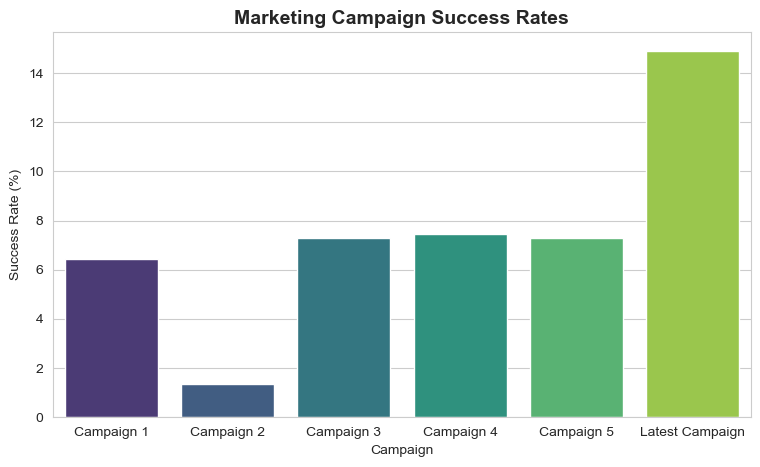

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

plt.figure(figsize=(9,5))

sns.barplot(
    x=campaign_performance_t.index,
    y=campaign_performance_t["Success Rate (%)"],
    hue=campaign_performance_t.index,
    palette="viridis",
    legend=False
)

plt.title("Marketing Campaign Success Rates", fontsize=14, weight="bold")
plt.xlabel("Campaign")
plt.ylabel("Success Rate (%)")

plt.savefig("campaign_success_rates.png", dpi=300, bbox_inches="tight")
plt.show()

## SQL Query 4 - Do high-spending customers respond more to campaigns?

In [19]:
query = """
SELECT
    CASE
        WHEN Total_Spend >= 1000 THEN 'High Value'
        WHEN Total_Spend >= 500 THEN 'Medium Value'
        ELSE 'Low Value'
    END AS customer_value_segment,

    COUNT(*) AS customers,
    ROUND(AVG(Response)*100,2) AS latest_campaign_response_rate

FROM customers

GROUP BY customer_value_segment
ORDER BY latest_campaign_response_rate DESC
"""

campaign_value_response = pd.read_sql(query, conn)

campaign_value_response

,customer_value_segment,customers,latest_campaign_response_rate
0,High Value,602,28.41
1,Medium Value,393,10.43
2,Low Value,1245,9.80


### Insight

High-value customers show the strongest response to the latest marketing campaign, with a response rate of 28.4%, compared with 10.4% for medium-value customers and 9.8% for low-value customers.

### Business Interpretation

This suggests that the campaign is successfully targeting the most valuable customers. Focusing marketing resources on high-spending customers appears to be an effective strategy for maximizing revenue.

## SQL Query 5 - Do customers with children spend more or less?

In [20]:
query = """
SELECT
    CASE
        WHEN Kidhome + Teenhome > 0 THEN 'Has Children'
        ELSE 'No Children'
    END AS household_type,

    COUNT(*) AS customers,
    ROUND(AVG(Total_Spend),2) AS avg_spend,
    ROUND(SUM(Total_Spend),2) AS total_revenue

FROM customers

GROUP BY household_type
ORDER BY avg_spend DESC
"""

children_spend = pd.read_sql(query, conn)

children_spend

,household_type,customers,avg_spend,total_revenue
0,No Children,638,1106.03,705647.0
1,Has Children,1602,406.58,651341.0


### Insight

Customers without children spend significantly more on average (£1106) than customers with children (£406).

### Business Interpretation

Despite representing a smaller portion of the customer base, households without children generate higher total revenue. This suggests they are a particularly valuable customer segment.

### Strategic Recommendation

Marketing campaigns and premium product promotions may be more effective when targeted toward customers without children, as they demonstrate significantly higher spending behaviour.

## Customer segment comparison

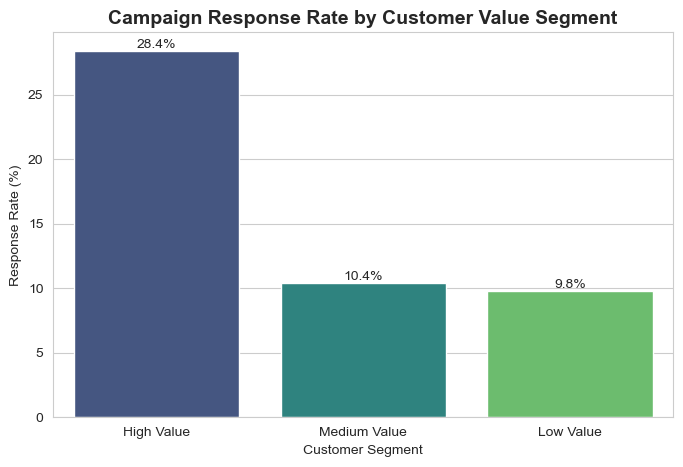

In [21]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=campaign_value_response,
    x="customer_value_segment",
    y="latest_campaign_response_rate",
    hue="customer_value_segment",
    palette="viridis",
    legend=False
)

for i in ax.containers:
    ax.bar_label(i, fmt='%.1f%%')

plt.title("Campaign Response Rate by Customer Value Segment", fontsize=14, weight="bold")
plt.xlabel("Customer Segment")
plt.ylabel("Response Rate (%)")

plt.savefig("campaign_response_rates.png", dpi=300, bbox_inches="tight")
plt.show()

### SQL Query 6 - Customer tenure and spending behaviour

In [22]:
import datetime as dt

today = dt.datetime(2014, 12, 31)

df["Customer_Tenure_Days"] = (today - df["Dt_Customer"]).dt.days

check it

In [23]:
df[["Dt_Customer","Customer_Tenure_Days"]].head()

,Dt_Customer,Customer_Tenure_Days
0,2012-09-04,848
1,2014-03-08,298
2,2013-08-21,497
3,2014-02-10,324
4,2014-01-19,346


### Create tenure segments

In [24]:
df.to_sql("customers", conn, if_exists="replace", index=False)

2240

In [25]:
query = """
SELECT
    CASE
        WHEN Customer_Tenure_Days < 365 THEN 'New Customers'
        WHEN Customer_Tenure_Days < 730 THEN 'Established Customers'
        ELSE 'Loyal Customers'
    END AS tenure_segment,

    COUNT(*) AS customers,
    ROUND(AVG(Total_Spend),2) AS avg_spend,
    ROUND(SUM(Total_Spend),2) AS total_revenue

FROM customers

GROUP BY tenure_segment
ORDER BY avg_spend DESC
"""

tenure_spend = pd.read_sql(query, conn)

tenure_spend

,tenure_segment,customers,avg_spend,total_revenue
0,Loyal Customers,494,745.48,368269.0
1,Established Customers,1189,601.70,715425.0
2,New Customers,557,490.65,273294.0


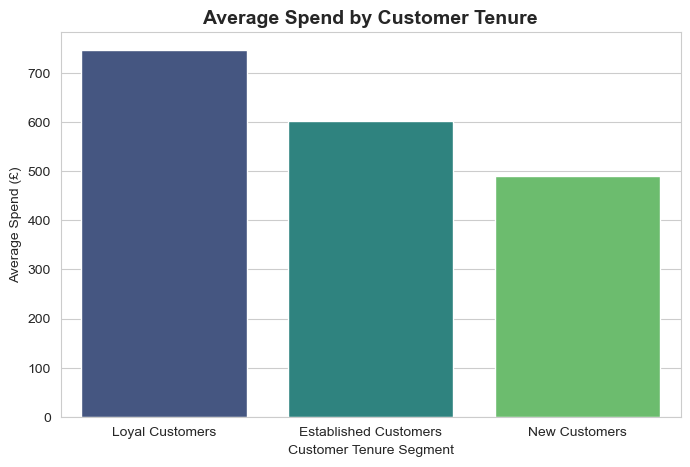

In [26]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=tenure_spend,
    x="tenure_segment",
    y="avg_spend",
    hue="tenure_segment",
    palette="viridis",
    legend=False
)

plt.title("Average Spend by Customer Tenure", fontsize=14, weight="bold")
plt.xlabel("Customer Tenure Segment")
plt.ylabel("Average Spend (£)")

plt.savefig("customer_tenure.png", dpi=300, bbox_inches="tight")
plt.show()

**Insight**

Customers with longer tenure tend to generate higher average spending. This suggests that customer retention and long-term relationships may significantly contribute to overall revenue.

**Business Interpretation**

Investing in customer retention strategies such as loyalty programs or personalised marketing may increase lifetime customer value.

## Key Business Insights

### 1. Education and Spending

Customers with PhD-level education show the highest average spending, suggesting higher education levels may correlate with greater purchasing power.

### 2. Marketing Campaign Performance

The most recent marketing campaign achieved the highest success rate (14.9%), significantly outperforming earlier campaigns.

### 3. Customer Value Segmentation

High-value customers (spending £1000+) show a much higher response rate (28.4%) to marketing campaigns, indicating that targeting high-spending customers is an effective marketing strategy.

### 4. Household Spending Behaviour

Customers without children spend significantly more on average (£1106) than customers with children (£406), and generate higher overall revenue despite representing a smaller segment of the customer base.

## Final Recommendations

- Continue prioritising high-value customers in marketing campaigns, as they show the strongest response rates.
- Review the design and targeting of Campaign 2, which materially underperformed the other campaigns.
- Consider tailored marketing for customers without children, as this segment shows significantly higher average spend and total revenue.
- Maintain separate strategies for broad-revenue segments and high-spend segments, since the largest customer groups are not always the highest value per customer.